# Data Cleaning


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import itertools
from scipy.stats import boxcox, skew, zscore
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root / "src/02_data_preperation"))

from data_cleaning import missing_strategy, plot_heatmap, skewness_overview

In [2]:
inner_close_sec_uncleaned = pd.read_csv(project_root / "data/inner_close_sec_uncleaned.csv")

In [3]:
inner_close_sec_uncleaned.isnull().sum()

issuer.tradingSymbol         0
reportingOwner.name          0
transactionDate              0
amounts.shares               0
amounts.pricePerShare        0
                         ...  
745                      11094
746                      11093
747                      11092
748                      11090
749                      11088
Length: 772, dtype: int64

In [4]:
crtf_missing_removed = missing_strategy(inner_close_sec_uncleaned,
                      default_missing_strategy="delete",
                      except_replace_0=[],
                      except_replace_mean=[],
                      except_delete=[])

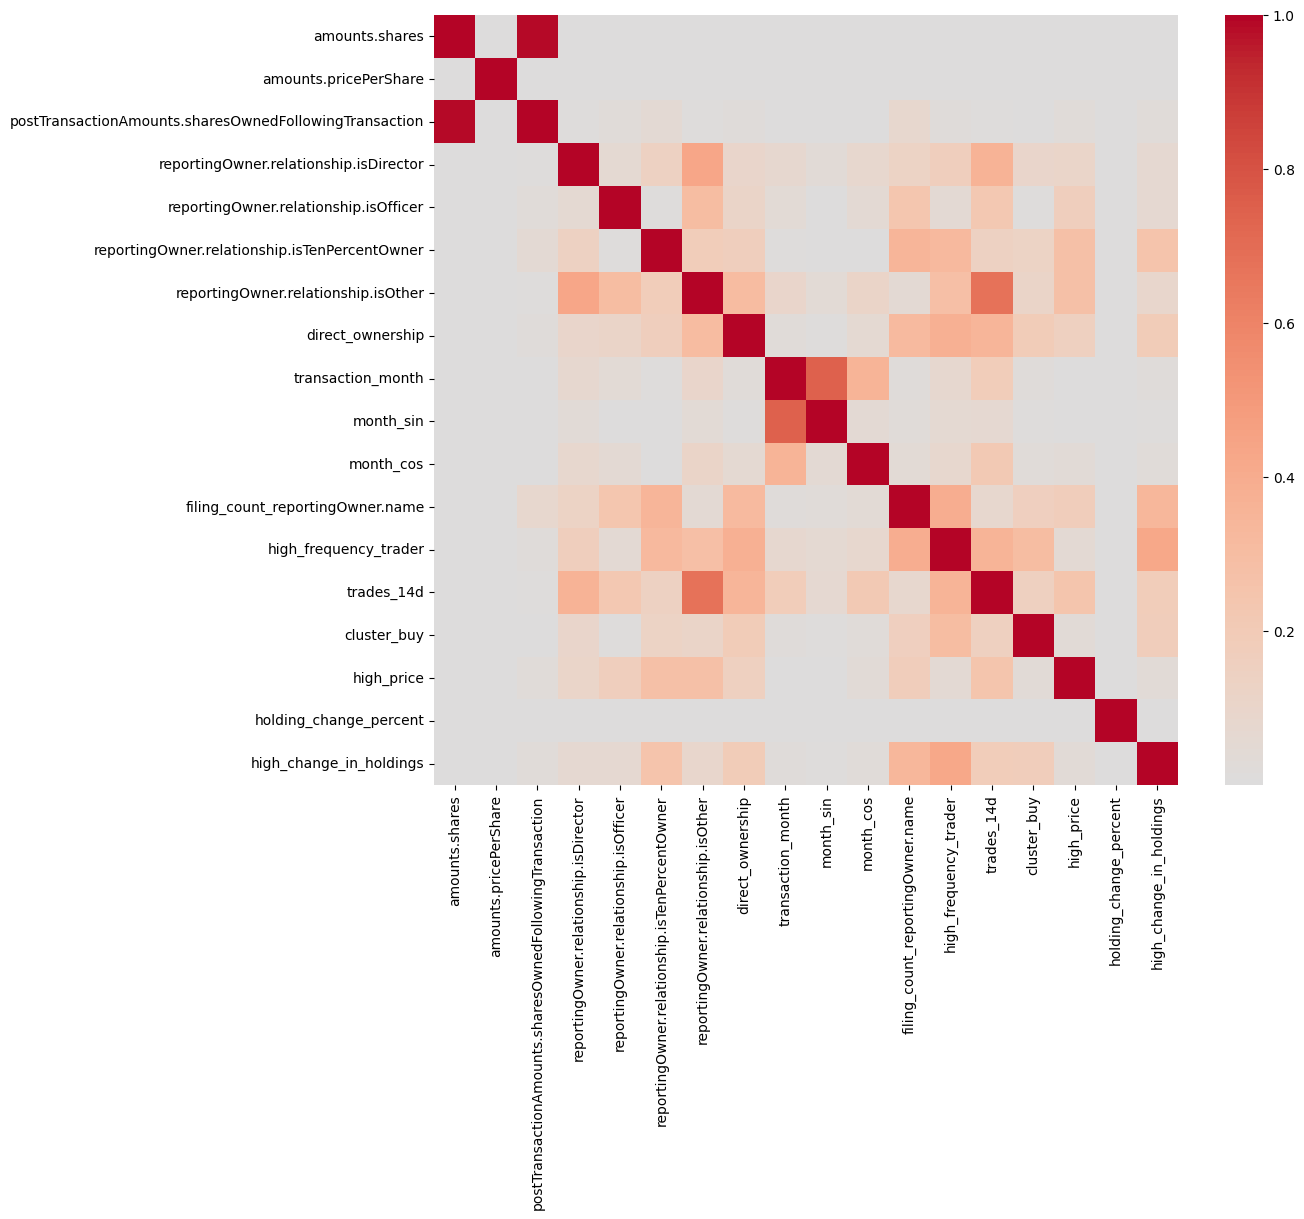

In [7]:
non_str = crtf_missing_removed.select_dtypes(include=["number", "bool"]).columns
non_str = [c for c in non_str if not (str(c).isdigit() and 0 <= int(c) <= 750)]
df_numeric = crtf_missing_removed[non_str]

plot_heatmap(df_numeric[non_str])
crtf_mhighcor_removed = crtf_missing_removed.drop(columns="postTransactionAmounts.sharesOwnedFollowingTransaction")

In [ ]:
num_cols = crtf_mhighcor_removed.select_dtypes(include=["number", "bool"]).columns
num_cols = [c for c in num_cols if not (str(c).isdigit() and 0 <= int(c) <= 750)]
df_numeric = crtf_mhighcor_removed[num_cols]
variances = df_numeric.var(skipna=True, ddof=1)
variances

amounts.shares                      6.303370e+16
amounts.pricePerShare               1.823910e+11
direct_ownership                    2.475631e-01
transaction_month                   1.188478e+01
month_sin                           5.059866e-01
month_cos                           4.926709e-01
filing_count_reportingOwner.name    6.028843e+06
high_frequency_trader               2.487202e-01
trades_14d                          4.389852e+05
cluster_buy                         1.153828e-01
high_price                          2.436531e-01
holding_change_percent              2.319194e+10
high_change_in_holdings             2.496748e-01
dtype: float64

In [16]:
crtf_missing_removed = crtf_mhighcor_removed.drop(columns=["cluster_buy", "holding_change_percent"])
crtf_missing_removed.to_csv(project_root / "data/raw.csv")

In [ ]:
num_cols = crtf_missing_removed.select_dtypes(include=["number", "bool"]).columns
num_cols = [c for c in num_cols if not (str(c).isdigit() and 0 <= int(c) <= 750)]
df_numeric = crtf_missing_removed[num_cols]
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_counts = ((df_numeric < lower) | (df_numeric > upper)).sum()
outlier_counts

amounts.shares                      32904
amounts.pricePerShare               12694
direct_ownership                        0
transaction_month                       0
month_sin                               0
month_cos                               0
filing_count_reportingOwner.name    41669
high_frequency_trader                   0
trades_14d                          42062
high_price                              0
high_change_in_holdings                 0
dtype: int64

In [18]:
mask = ~((df_numeric < lower) | (df_numeric > upper)).any(axis=1)

crtf_outlier_removed = crtf_missing_removed[mask]
crtf_outlier_removed

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,...,740,741,742,743,744,745,746,747,748,749
0,ANTP,INZER DEBORAH,2009-01-29,1000.0,2.5000,D,False,True,False,False,...,3.720000,3.830000,3.710100,3.880000,3.880000,3.880000,3.819900,3.650000,3.630000,3.640000
2,HBNC,NEFF JAMES D,2009-01-30,6000.0,12.5000,D,False,True,False,False,...,3.501738,3.576777,3.600539,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302
3,HBNC,NEFF JAMES D,2009-01-30,4000.0,12.4975,D,False,True,False,False,...,3.501738,3.576777,3.600539,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302
4,WLFC,JACOBS SY,2009-01-28,1910.0,8.6000,I,False,False,True,False,...,13.063982,13.073694,13.073694,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130
5,WLFC,JACOBS SY,2009-01-29,613.0,8.6600,I,False,False,True,False,...,13.073694,13.073694,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130,13.034844
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252705,SPE,GOLDSTEIN PHILLIP,2023-12-28,44.0,11.7500,D,True,True,False,False,...,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709
252706,SPE,GOLDSTEIN PHILLIP,2023-12-28,1319.0,11.7800,D,True,True,False,False,...,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709
252707,SFBC,STILWELL JOSEPH,2023-12-28,7.0,38.7500,I,False,False,True,False,...,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849
252708,SFBC,STILWELL JOSEPH,2023-12-29,404.0,39.0000,I,False,False,True,False,...,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849


In [ ]:
skewness_overview(df_numeric)

,Row,original,log(x),log1p,sqrt,boxcox,power_transform
0,amounts.shares,488.421,-0.273,-0.131,426.216,-0.0,-0.002
1,amounts.pricePerShare,399.758,1.096,1.33,190.065,-0.002,0.022
2,direct_ownership,-0.198,not applicable because 0 or negative value,-0.198,-0.198,not calculable because values smaller then 0,-0.198
3,transaction_month,-0.079,-1.002,-0.75,-0.463,-0.225,-0.183
4,month_sin,0.084,not applicable because 0 or negative value,not calculable because values smaller then -1,not calculable because of values smaller then 0,not calculable because values smaller then 0,0.033
5,month_cos,-0.023,not applicable because 0 or negative value,not calculable because values smaller then -1,not calculable because of values smaller then 0,not calculable because values smaller then 0,-0.015
6,filing_count_reportingOwner.name,2.961,0.266,0.379,2.0,0.038,0.068
7,high_frequency_trader,-0.144,not applicable because 0 or negative value,-0.144,-0.144,not calculable because values smaller then 0,-0.144
8,trades_14d,2.643,0.994,1.174,2.163,0.183,0.283
9,high_price,-0.323,not applicable because 0 or negative value,-0.323,-0.323,not calculable because values smaller then 0,-0.323


In [27]:
crtf_skewness = crtf_outlier_removed
crtf_skewness["boxcox_amounts_shares"],_ = boxcox(crtf_skewness["amounts.shares"])
crtf_skewness["boxcox_amounts.pricePerShare"],_ = boxcox(crtf_skewness["amounts.pricePerShare"])
crtf_skewness = crtf_skewness.drop(columns=["amounts.shares", "amounts.pricePerShare"])
crtf_skewness

C:\Users\tsymb\AppData\Local\Temp\ipykernel_37444\3768453361.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crtf_skewness["boxcox_amounts_shares"],_ = boxcox(crtf_skewness["amounts.shares"])
C:\Users\tsymb\AppData\Local\Temp\ipykernel_37444\3768453361.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crtf_skewness["boxcox_amounts.pricePerShare"],_ = boxcox(crtf_skewness["amounts.pricePerShare"])


,issuer.tradingSymbol,reportingOwner.name,transactionDate,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,direct_ownership,transaction_month,...,742,743,744,745,746,747,748,749,boxcox_amounts_shares,boxcox_amounts.pricePerShare
0,ANTP,INZER DEBORAH,2009-01-29,D,False,True,False,False,1,1,...,3.710100,3.880000,3.880000,3.880000,3.819900,3.650000,3.630000,3.640000,12.788151,0.960514
2,HBNC,NEFF JAMES D,2009-01-30,D,False,True,False,False,1,1,...,3.600539,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302,19.211383,2.881239
3,HBNC,NEFF JAMES D,2009-01-30,D,False,True,False,False,1,1,...,3.600539,3.600539,3.600539,3.611793,3.611793,3.626802,3.618046,3.629302,17.589295,2.880981
4,WLFC,JACOBS SY,2009-01-28,I,False,False,True,False,0,1,...,13.073694,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130,14.894602,2.406397
5,WLFC,JACOBS SY,2009-01-29,I,False,False,True,False,0,1,...,13.229106,13.015418,13.015418,13.015418,13.015418,12.986280,13.025130,13.034844,11.336428,2.415061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252705,SPE,GOLDSTEIN PHILLIP,2023-12-28,D,True,True,False,False,1,12,...,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,5.234962,2.801416
252706,SPE,GOLDSTEIN PHILLIP,2023-12-28,D,True,True,False,False,1,12,...,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,9.395709,13.662286,2.804696
252707,SFBC,STILWELL JOSEPH,2023-12-28,I,False,False,True,False,0,12,...,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,2.290256,4.433340
252708,SFBC,STILWELL JOSEPH,2023-12-29,I,False,False,True,False,0,12,...,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,37.531849,10.187822,4.442684


In [28]:
scale_cols = ["filing_count_reportingOwner.name", "trades_14d"]
crtf_scaled = crtf_skewness
for c in scale_cols:
    crtf_scaled[c] = zscore(crtf_skewness[c])

In [29]:
crtf_scaled.to_csv(project_root / "data/cleaned.csv")